# Проверка работоспособности алгоритма рекурсивного приближения

In [2]:
import osmnx as ox
import geopandas as gpd
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [6]:
# Данные
G = ox.load_graphml("tests/data/test_rng.ml")
# G = ox.simplify_graph(g)
area = gpd.read_file("tests/data/test_polygon.gpkg")

# здания
b = gpd.read_file("tests/data/buildings.gpkg", layer='здания')
b = b[['osmid', 'building', 'demand', 'geometry']]   # 'name', 'amenity', 
b = b.set_index('osmid')
print('Всего зданий:', len(b))

nodes = ox.graph_to_gdfs(G, edges=False)
area_nodes = nodes.within(area.iloc[0].geometry)
nodes_list=set(nodes[area_nodes].index)

print('Узлов в графе:', len(nodes))
print('Узлов в пределах area:', len(nodes_list))

Всего зданий: 1591
Узлов в графе: 5514
Узлов в пределах area: 2240


step 1 - 9086103717, 8.855574151175768
step 2 - 1998227467, 8.531546179856207
ВРЕМЯ: 14.92 сек
Наиболее выгодная точка размещения: 6222357784
Среднее время следования в любую точку города: 8.490200729313747 мин


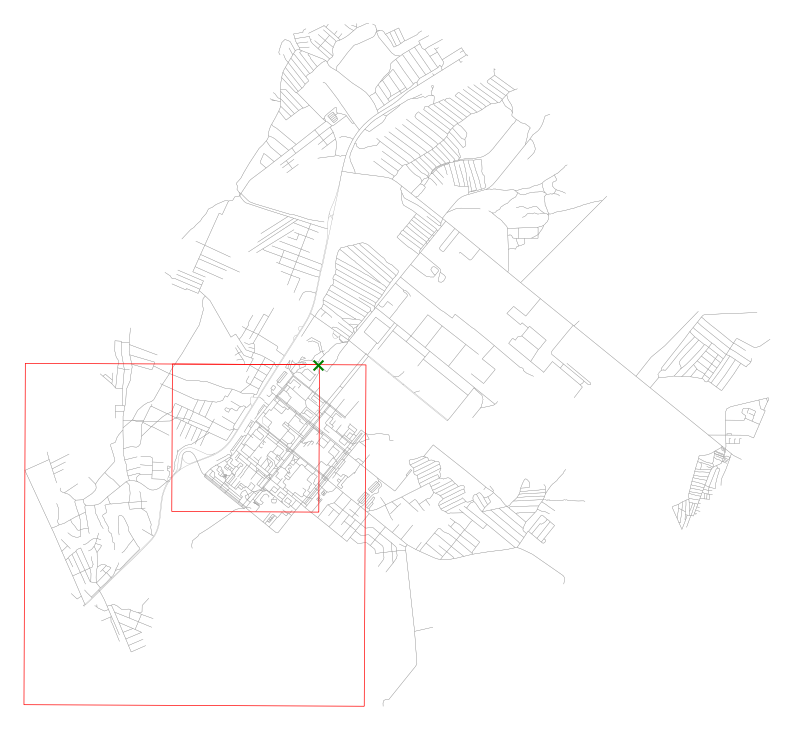

In [30]:
import random
import math

import shapely
from genesis.core import BestPointsBase, StateBase, MetricBase
from genesis.best_points import NodeMetric
from genesis.metrics import ArrivalTime
from genesis.states import FirstArrivalUnitState
from genesis.utils import timing

class BestNodeSquareZoom(BestPointsBase):
    """
    Поиск лучшего узла графа методом рекурсивного деления области на квадраты.
    1. Проекция графа в локальную систему координат.
    2. Определение главного прямоугольника, в который вписаны узлы графа.
    3. Разбиение прямоугольника на квадраты со стороной min(width, height)/2.
    4. В каждом квадрате случайная выборка до n узлов и вычисление метрики.
    5. Выбор квадрата с узлом наилучшей метрики и рекурсия, пока количество узлов в квадрате не <= n_min_count.
    """
    def __init__(self, state_function: StateBase,
                metric_function: MetricBase,
                n_samples: int = 10,
                n_min_count: int = 5,
                step_end_function: callable = None,
                **kwargs):
        """
        `state_function`: StateBase — функция расчета состояния окружения.
        `metric_function`: MetricBase — функция расчета метрики.
        `n_samples`: int — максимальное число узлов для оценки в каждом квадрате.
        `n_min_count`: int — минимальное число узлов для останова рекурсии.
        `step_end_function` - функция, вызываемая после каждого шага рекурсии.
        """
        self.n_samples = n_samples
        self.n_min_count = n_min_count
        self.step_end_function = step_end_function
        super().__init__(state_function, metric_function, **kwargs)

    def __call__(self, env: nx.Graph,
                area=None, 
                start_point: int = None,
                points_list: set = None,
                **kwargs) -> tuple[int | None, float | None]:
        """
        `env`: MultiDiGraph — граф улично-дорожной сети.
        `area`: pandas.Series — маска узлов графа для расчёта доступности (см. NodeMetric).
        `start_point`: не используется.
        `points_list`: set — начальный набор узлов-кандидатов.
        Возвращает `(best_node, best_metric)`.
        """
        # Подготовка исходных узлов
        if points_list is None:
            current_nodes = list(env.nodes())
        else:
            current_nodes = list(points_list)
        # Проекция графа
        # Проекция графа только если он в географической системе координат
        if env.graph['crs'] == 'epsg:4326':
            G = ox.project_graph(env)
        else:
            G = env
        node_metric_fn = NodeMetric(self.state_function, self.metric_function)
        best_node = None
        best_metric = None

        level = 1
        # best_squares = []
        while True:
            # Координаты узлов
            xs = [G.nodes[u]['x'] for u in current_nodes]
            ys = [G.nodes[u]['y'] for u in current_nodes]
            x_min, x_max = min(xs), max(xs)
            y_min, y_max = min(ys), max(ys)
            dx, dy = x_max - x_min, y_max - y_min
            size = min(dx, dy) / 2
            # Создание квадратов
            nx_squares = int(math.ceil(dx / size))
            ny_squares = int(math.ceil(dy / size))
            squares = []
            for i in range(nx_squares):
                for j in range(ny_squares):
                    x0, y0 = x_min + i * size, y_min + j * size
                    squares.append((x0, y0, x0 + size, y0 + size))
            # Оценка квадратов
            best_node_sq = None
            best_metric_sq = None
            best_square_nodes = None
            square = 1
            best_square = None
            for x0, y0, x1, y1 in squares:
                # Узлы в квадрате
                nodes_sq = [u for u in current_nodes if x0 <= G.nodes[u]['x'] <= x1 and y0 <= G.nodes[u]['y'] <= y1]
                if not nodes_sq:
                    continue
                # Выборка узлов
                if len(nodes_sq) > self.n_samples:
                    sample = random.sample(nodes_sq, self.n_samples)
                else:
                    sample = nodes_sq
                # Оценка узлов
                for u in sample:
                    node_metric = node_metric_fn(env=G, node=u, area=area, **kwargs)
                    if node_metric is None:
                        continue
                    if best_metric_sq is None or self.metric_function.compare(node_metric, best_metric_sq) == node_metric:
                        best_metric_sq = node_metric
                        best_node_sq = u
                        best_square_nodes = nodes_sq
                        best_square = (x0, y0, x1, y1)
                # print(f'square {square} - {best_node_sq}, {best_metric_sq}')
                square += 1
            # best_squares.append(best_square)
            if best_node_sq is None:
                break
            best_node, best_metric = best_node_sq, best_metric_sq
            # Проверка условия останова
            if len(best_square_nodes) <= self.n_min_count:
                break
            # Переход к узлам лучшего квадрата
            current_nodes = best_square_nodes
            # Печать результата
            if self.step_end_function is not None:
                self.step_end_function(
                    step        = level,
                    best_node   = best_node,
                    best_metric = best_metric,
                    best_square = best_square)
            # Уменьшение масштаба квадратов
            # print(f'level {level} - {best_node}, {best_metric}')
            level += 1

        return best_node, best_metric  #, best_squares


# ===============================================================
best_squares = []
def step_end_function(step, best_node, best_metric, best_square):
    print(f'step {step} - {best_node}, {best_metric}')
    best_squares.append(best_square)


# Инициализация алгоритма
blp = timing(BestNodeSquareZoom(
    state_function    = FirstArrivalUnitState(),
    metric_function   = ArrivalTime(),
    n_samples         = 10,
    n_min_count       = 5,
    step_end_function = step_end_function,
    ))

# Расчет лучшего размещения
best_node, best_metric = blp(env=G)


# Печать результата
print('Наиболее выгодная точка размещения:', best_node)
print('Среднее время следования в любую точку города:', best_metric, 'мин')


def plot_map(G, best_squares, ):
    # Визуализация ГДС с оптимальной точкой размещения и квадратами последовательного приближения
    geometry = [shapely.geometry.box(x0, y0, x1, y1) for x0, y0, x1, y1 in best_squares]

    boxes = gpd.GeoDataFrame(geometry, columns=['geometry'], crs=ox.project_graph(G).graph['crs'])
    boxes = ox.projection.project_gdf(boxes, to_latlong=True)

    fig, ax = plt.subplots(figsize=(10, 10))
    ox.plot_graph(G, ax=ax, node_size=0, edge_linewidth=0.2, show=False, close=False, bgcolor='white')
    boxes.boundary.plot(ax=ax, color='red', linewidth=0.5)
    ox.graph_to_gdfs(G, edges=False).loc[[best_node]].plot(ax=ax, color='g', marker='x', 
                                                        markersize=50, zorder=10)
    plt.show()

plot_map(G, best_squares)

<span style="color: red">НАДО РАЗБИРАТЬСЯ!!!</style>

step 1 - 1555151973, 4.672684777923239
step 2 - 9085465280, 4.485631363273517
step 3 - 1545616076, 4.634182257264193
step 4 - 1577701962, 4.328401644772975
ВРЕМЯ: 21.44 сек
Наиболее выгодная точка размещения: 1550092538
Среднее время следования в любую точку города: 4.3484172741235065 мин


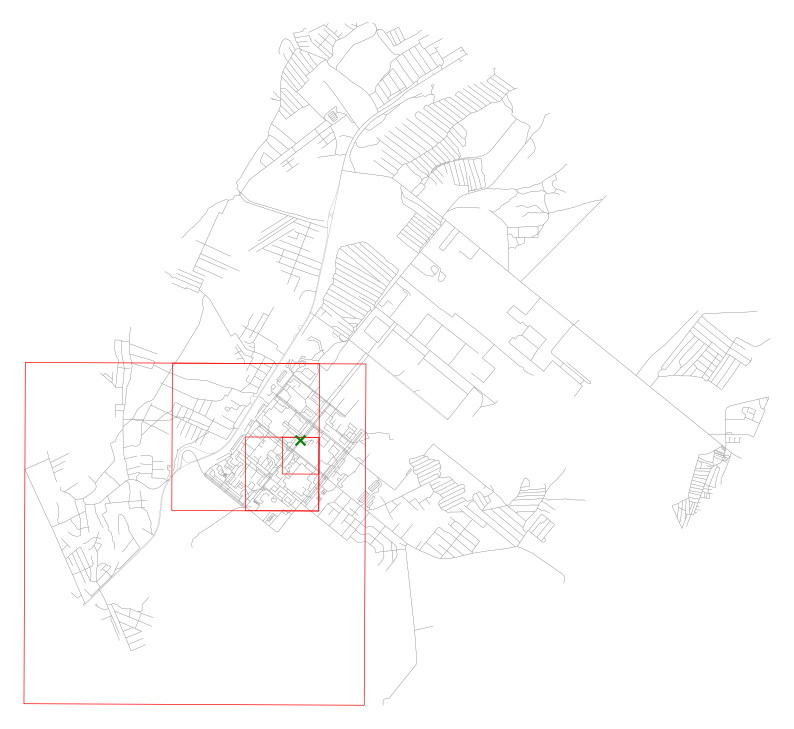

In [29]:
# Расчет лучшего размещения
best_squares = []
best_node, best_metric = blp(env=G, area=area_nodes)


# Печать результата
print('Наиболее выгодная точка размещения:', best_node)
print('Среднее время следования в любую точку города:', best_metric, 'мин')

plot_map(G, best_squares)

|########################################| 100.0%
Наиболее выгодные точки размещения: 426923808
Среднее время следования в любую точку города: 8.355415617070701 мин
|########################################| 100.0%
Наиболее выгодные точки размещения: 1577701962
Среднее время следования в любую точку города: 4.328401644772975 мин


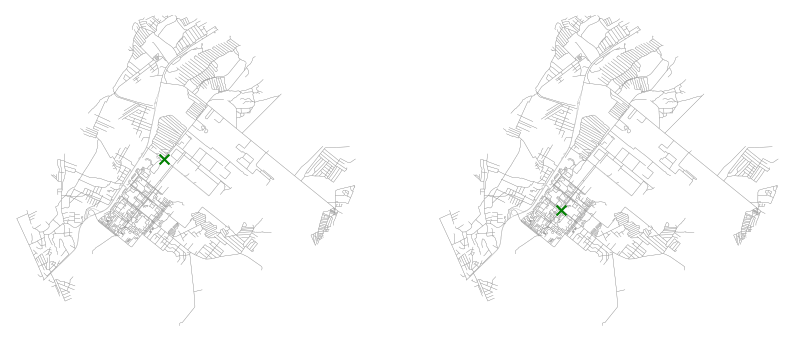

In [12]:
from genesis.best_points import BestNodesFull
from genesis.utils import Progressbar, timing


# Расчет лучшего размещения
full = timing(BestNodesFull(
    state_function = FirstArrivalUnitState(),
    metric_function = ArrivalTime(),
    node_calc_end_function = Progressbar(G.number_of_nodes())
))
best_node, best_metric = full(G)
# Печать результата
print('Наиболее выгодные точки размещения:', best_node)
print('Среднее время следования в любую точку города:', best_metric, 'мин')

# Расчет лучшего размещения в области
full = timing(BestNodesFull(
    state_function = FirstArrivalUnitState(),
    metric_function = ArrivalTime(),
    node_calc_end_function = Progressbar(G.number_of_nodes())
))
best_node_a, best_metric_a = full(G, area=area_nodes)
# Печать результата
print('Наиболее выгодные точки размещения:', best_node_a)
print('Среднее время следования в любую точку города:', best_metric_a, 'мин')


fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10, 10))

ox.plot_graph(G, ax=ax1, node_size=0, edge_linewidth=0.2, show=False, close=False, bgcolor='white')
ox.graph_to_gdfs(G, edges=False).loc[[best_node]].plot(ax=ax1, color='g', marker='x', 
                                                    markersize=50, zorder=10)

ox.plot_graph(G, ax=ax2, node_size=0, edge_linewidth=0.2, show=False, close=False, bgcolor='white')
ox.graph_to_gdfs(G, edges=False).loc[[best_node_a]].plot(ax=ax2, color='g', marker='x', 
                                                    markersize=50, zorder=10)

plt.show()